In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
cc_calls = pd.read_csv('../../data/raw/cc_calls.csv', low_memory=False)
cc_calls.columns = cc_calls.columns.str.lower().str.replace(' ', '_')
cc_calls.shape

(32882, 33)

Dropping duplicate rows

In [57]:
cc_calls.duplicated().sum()

np.int64(93)

In [58]:
cc_calls = cc_calls.drop_duplicates()
cc_calls.shape

(32789, 33)

Dropping rows with null co_ref

In [59]:
cc_calls['co_ref'].isnull().sum()

np.int64(1153)

In [60]:
cc_calls = cc_calls.dropna(subset=['co_ref'])
cc_calls.shape

(31636, 33)

Standardizing values in direction column

In [61]:
cc_calls['direction'].value_counts()

direction
OUT_BOUND    24292
IN_BOUND      7344
Name: count, dtype: int64

In [62]:
cc_calls['direction'] = cc_calls['direction'].replace({
    'OUT_BOUND': 'Outbound',
    'IN_BOUND': 'Inbound'
})
cc_calls['direction'].value_counts()

direction
Outbound    24292
Inbound      7344
Name: count, dtype: int64

Converting proper datatype of dates

In [63]:
cc_calls['call_date'].head()

0    08-05-2025
1    25-11-2024
2    23-10-2024
3    13-01-2025
4    19-03-2025
Name: call_date, dtype: str

In [64]:
cc_calls['call_date'] = pd.to_datetime(cc_calls['call_date'], format='%d-%m-%Y')
cc_calls['call_date'].head()

0   2025-05-08
1   2024-11-25
2   2024-10-23
3   2025-01-13
4   2025-03-19
Name: call_date, dtype: datetime64[us]

Handling score columns

In [65]:
score_columns = [
    'cc_contractor_sentiment_start_score', 
    'cc_contractor_sentiment_end_score', 
    'cc_contractor_sentiment_overall_score', 
    'cc_contractor_sentiment_issues_score'
]
cc_calls[score_columns].dtypes

cc_contractor_sentiment_start_score      str
cc_contractor_sentiment_end_score        str
cc_contractor_sentiment_overall_score    str
cc_contractor_sentiment_issues_score     str
dtype: object

In [66]:
for col in score_columns:
    cc_calls[col] = pd.to_numeric(cc_calls[col], errors='coerce')
cc_calls[score_columns].dtypes

cc_contractor_sentiment_start_score      float64
cc_contractor_sentiment_end_score        float64
cc_contractor_sentiment_overall_score    float64
cc_contractor_sentiment_issues_score     float64
dtype: object

Dropping irrelevant columns<br>
1- analysed_call -> has only one unique value<br>
2- call_year -> can be derived from call_date<br>
3- contact_id -> is unique identifier so wont be used for prediction

In [67]:
cc_calls['analysed_call'].unique()

array([1])

In [68]:
cc_calls['call_year'].unique()

array([2025, 2024, 2026])

In [69]:
cc_calls['contact_id'].nunique()

494

In [70]:
cc_calls = cc_calls.drop(columns=['analysed_call', 'call_year', 'contact_id'])
cc_calls.shape

(31636, 30)

Handling columns that should only contain Yes or No

In [71]:
yes_no_columns = [
    'cc_care_package_discussed', 'cc_urgency_getting_on_site',
    'cc_external_consultant', 'cc_agent_cross_sell_attempt',
    'cc_customer_issues_concerns', 'cc_business_struggles_financial_hardship',
    'cc_questionnaire_completion', 'cc_chasing_response',
    'cc_issues_within_questionnaire', 'cc_login_issues',
    'cc_platform_issues', 'cc_dissatisfaction_time_to_complete',
    'cc_process_complexity_concerns', 'cc_questions_harder_than_expected',
    'cc_dissatisfaction_support', 'cc_pricing_mentioned',
    'cc_pricing_sentiment_impact', 'cc_refund_discussed',
    'cc_contractor_suggest_leave', 'cc_contractor_complained'
]

for col in yes_no_columns:
    print(f"  {col}: {cc_calls[col].nunique()}")

  cc_care_package_discussed: 3
  cc_urgency_getting_on_site: 3
  cc_external_consultant: 3
  cc_agent_cross_sell_attempt: 23
  cc_customer_issues_concerns: 9
  cc_business_struggles_financial_hardship: 6
  cc_questionnaire_completion: 3
  cc_chasing_response: 169
  cc_issues_within_questionnaire: 58
  cc_login_issues: 12
  cc_platform_issues: 4
  cc_dissatisfaction_time_to_complete: 3
  cc_process_complexity_concerns: 24
  cc_questions_harder_than_expected: 7
  cc_dissatisfaction_support: 4
  cc_pricing_mentioned: 11
  cc_pricing_sentiment_impact: 8
  cc_refund_discussed: 5
  cc_contractor_suggest_leave: 64
  cc_contractor_complained: 15


In [72]:
for col in yes_no_columns:
    mode_val = cc_calls[col].mode()[0]
    print(cc_calls[col].value_counts())
    print(f"Mode = {mode_val}")
    print()

cc_care_package_discussed
No          24668
Yes          6809
[Yes/No]       23
Name: count, dtype: int64
Mode = No

cc_urgency_getting_on_site
No          28285
Yes          3192
[Yes/No]       23
Name: count, dtype: int64
Mode = No

cc_external_consultant
No          28110
Yes          3367
[Yes/No]       23
Name: count, dtype: int64
Mode = No

cc_agent_cross_sell_attempt
No                                                                                                 30304
Yes                                                                                                 1153
[Yes/No]                                                                                              23
 helps them with audits and possibly other accreditation processes."                                   1
 indicating that they have external support or accreditation."                                         1
 helps with the accreditation process                                                             

In [73]:
for col in yes_no_columns:
    mode_val = cc_calls[col].mode()[0]
    cc_calls[col] = cc_calls[col].where(cc_calls[col].isin(['Yes', 'No']), other=mode_val)

for col in yes_no_columns:
    print(f"  {col}: {cc_calls[col].nunique()}")

  cc_care_package_discussed: 2
  cc_urgency_getting_on_site: 2
  cc_external_consultant: 2
  cc_agent_cross_sell_attempt: 2
  cc_customer_issues_concerns: 2
  cc_business_struggles_financial_hardship: 2
  cc_questionnaire_completion: 2
  cc_chasing_response: 2
  cc_issues_within_questionnaire: 2
  cc_login_issues: 2
  cc_platform_issues: 2
  cc_dissatisfaction_time_to_complete: 2
  cc_process_complexity_concerns: 2
  cc_questions_harder_than_expected: 2
  cc_dissatisfaction_support: 2
  cc_pricing_mentioned: 2
  cc_pricing_sentiment_impact: 2
  cc_refund_discussed: 2
  cc_contractor_suggest_leave: 2
  cc_contractor_complained: 2


Handling null values in cc_calls

In [74]:
cc_calls.isnull().sum()[cc_calls.isnull().sum() > 0]

cc_care_package                            136
cc_call_initiated_by                       136
cc_contractor_sentiment                     95
cc_contractor_sentiment_start_score        235
cc_contractor_sentiment_end_score          234
cc_contractor_sentiment_overall_score     4796
cc_contractor_sentiment_issues_score     20948
dtype: int64

In [75]:
print('Total rows with null values:', cc_calls.isnull().any(axis=1).sum())

Total rows with null values: 20993


In [76]:
cols = [
    'cc_care_package',
    'cc_call_initiated_by',
    'cc_contractor_sentiment',
    'cc_contractor_sentiment_start_score',
    'cc_contractor_sentiment_end_score'
]

cc_calls = cc_calls.dropna(subset=cols)
cc_calls.shape

(31229, 30)

In [77]:
print('Total rows with null values:', cc_calls.isnull().any(axis=1).sum())

Total rows with null values: 20586


Column : cc_contractor_sentiment_overall_score
Mean   : 81.6
Median : 80.0


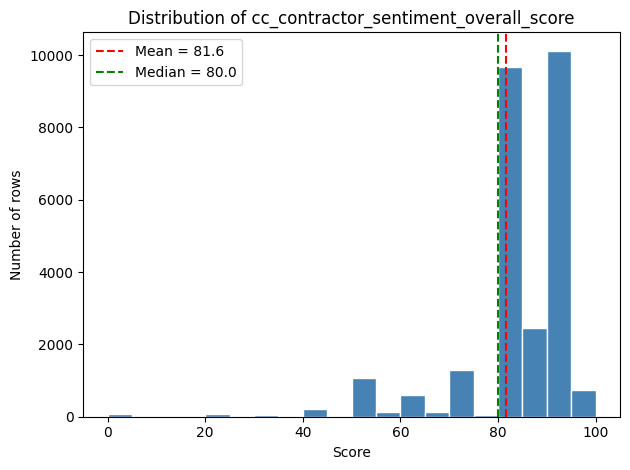

Column : cc_contractor_sentiment_issues_score
Mean   : 80.79
Median : 90.0


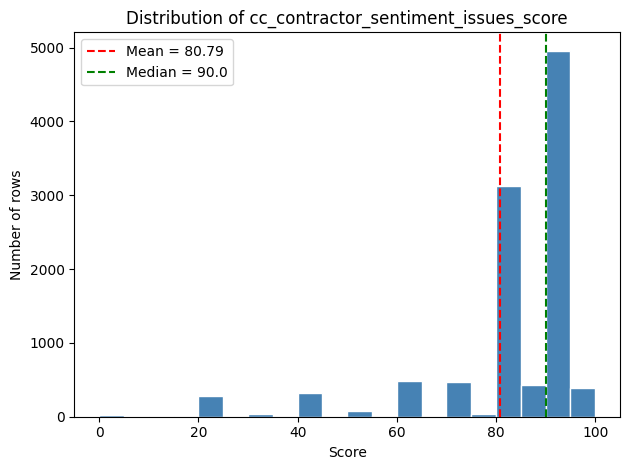

In [78]:
score_cols = [
    'cc_contractor_sentiment_overall_score',
    'cc_contractor_sentiment_issues_score'
]

for col in score_cols:
    data = cc_calls[col].dropna()
    mean_val   = round(data.mean(), 2)
    median_val = round(data.median(), 2)
    print(f"Column : {col}")
    print(f"Mean   : {mean_val}")
    print(f"Median : {median_val}")

    plt.figure()
    plt.hist(data, bins=20, color='steelblue', edgecolor='white')
    plt.axvline(mean_val,   color='red',   linestyle='--', label=f'Mean = {mean_val}')
    plt.axvline(median_val, color='green', linestyle='--', label=f'Median = {median_val}')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Score')
    plt.ylabel('Number of rows')
    plt.legend()
    plt.tight_layout()
    plt.show()

Histogram shows that both score columns are left skewed. So filling null values with median as it is not affected by outliers.

In [81]:
for col in score_fill_cols:
    median_val = cc_calls[col].median()
    cc_calls[col] = cc_calls[col].fillna(median_val)

cc_calls.isnull().sum()[cc_calls.isnull().sum() > 0]

Series([], dtype: int64)

Saving cleaned dataset

In [82]:
import os
os.makedirs('../../data/cleaned', exist_ok=True)
cc_calls.to_csv('../../data/cleaned/cc_calls_cleaned.csv', index=False)
print('Saved! Shape:', cc_calls.shape)

Saved! Shape: (31229, 30)
